In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# Simular "población completa" de Farmacias — ventas por ticket
# Log-normal porque ya sabemos que los tickets tienen cola derecha
poblacion = np.random.lognormal(mean=np.log(150), sigma=0.8, size=500_000)

print(f"Tamaño población:  {len(poblacion):,}")
print(f"Media poblacional: ${poblacion.mean():.2f}  ← este es el valor 'real'")
print(f"Std poblacional:   ${poblacion.std():.2f}")
print(f"Mediana:           ${np.median(poblacion):.2f}")

Tamaño población:  500,000
Media poblacional: $206.35  ← este es el valor 'real'
Std poblacional:   $194.33
Mediana:           $149.87


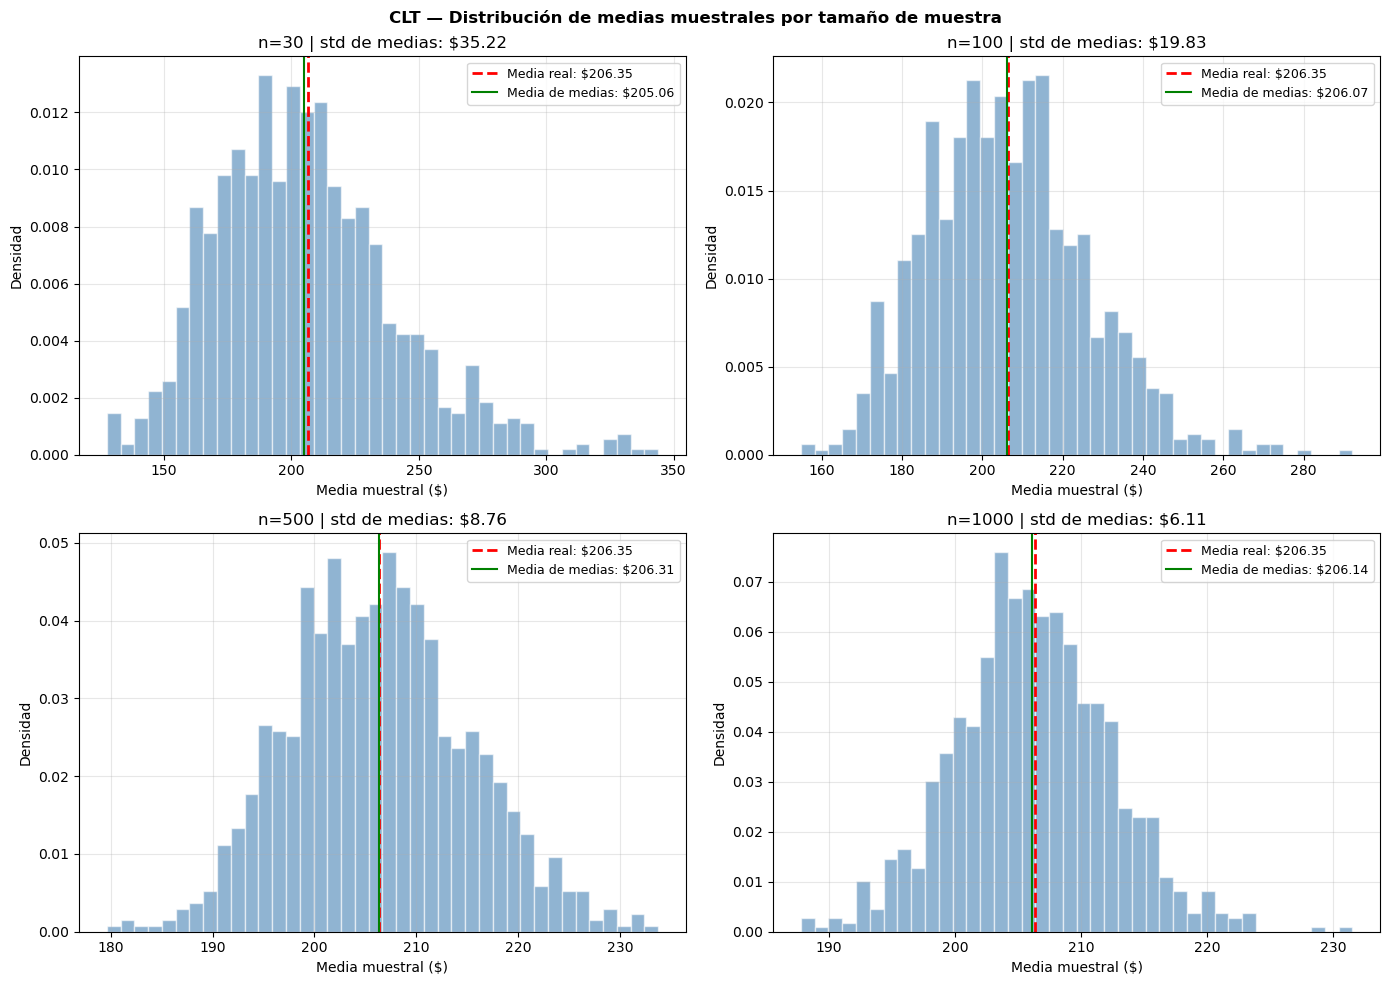

=== RESUMEN ===
Media real poblacional: $206.35

n=  30 | Media de medias: $205.06 | Std: $35.22 | Error: $1.29
n= 100 | Media de medias: $206.07 | Std: $19.83 | Error: $0.28
n= 500 | Media de medias: $206.31 | Std: $8.76 | Error: $0.05
n=1000 | Media de medias: $206.14 | Std: $6.11 | Error: $0.22


In [2]:
# ============================================================
# S4.3 — MUESTREO Y TEOREMA CENTRAL DEL LÍMITE (CLT)
# ============================================================

# Pregunta: si tomo muestras de n=1000 de una población de 500,000
# ¿qué tan cerca queda la media muestral de la media real ($206.35)?

media_real = poblacion.mean()

# Experimento: tomar 1,000 muestras distintas y calcular la media de cada una
n_muestras = 1000

resultados = {}

for n in [30, 100, 500, 1000]:
    medias = []
    for _ in range(n_muestras):
        muestra = np.random.choice(poblacion, size=n, replace=False)
        medias.append(muestra.mean())
    resultados[n] = np.array(medias)

# Visualizar
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (n, medias) in zip(axes.flatten(), resultados.items()):
    ax.hist(medias, bins=40, density=True, alpha=0.6,
            color='steelblue', edgecolor='white')
    ax.axvline(media_real, color='red', linewidth=2,
               linestyle='--', label=f'Media real: ${media_real:.2f}')
    ax.axvline(medias.mean(), color='green', linewidth=1.5,
               linestyle='-', label=f'Media de medias: ${medias.mean():.2f}')
    ax.set_title(f'n={n} | std de medias: ${medias.std():.2f}')
    ax.set_xlabel('Media muestral ($)')
    ax.set_ylabel('Densidad')
    ax.legend(fontsize=9)

plt.suptitle('CLT — Distribución de medias muestrales por tamaño de muestra',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/S4.3_CLT.png', dpi=150, bbox_inches='tight')
plt.show()

print("=== RESUMEN ===")
print(f"Media real poblacional: ${media_real:.2f}")
print()
for n, medias in resultados.items():
    error = abs(medias.mean() - media_real)
    print(f"n={n:4d} | Media de medias: ${medias.mean():.2f} | "
          f"Std: ${medias.std():.2f} | Error: ${error:.2f}")

=== ERROR ESTÁNDAR ===
σ poblacional: $194.33

n=  30 | Media: $193.88 | SE: $30.82 | IC 95%: [$133.48, $254.29] | ✅ captura la media real
n= 100 | Media: $195.95 | SE: $17.21 | IC 95%: [$162.23, $229.67] | ✅ captura la media real
n= 500 | Media: $223.32 | SE: $9.55 | IC 95%: [$204.60, $242.05] | ✅ captura la media real
n=1000 | Media: $207.09 | SE: $5.87 | IC 95%: [$195.58, $218.61] | ✅ captura la media real

=== VISUALIZACIÓN IC para n=1000 ===


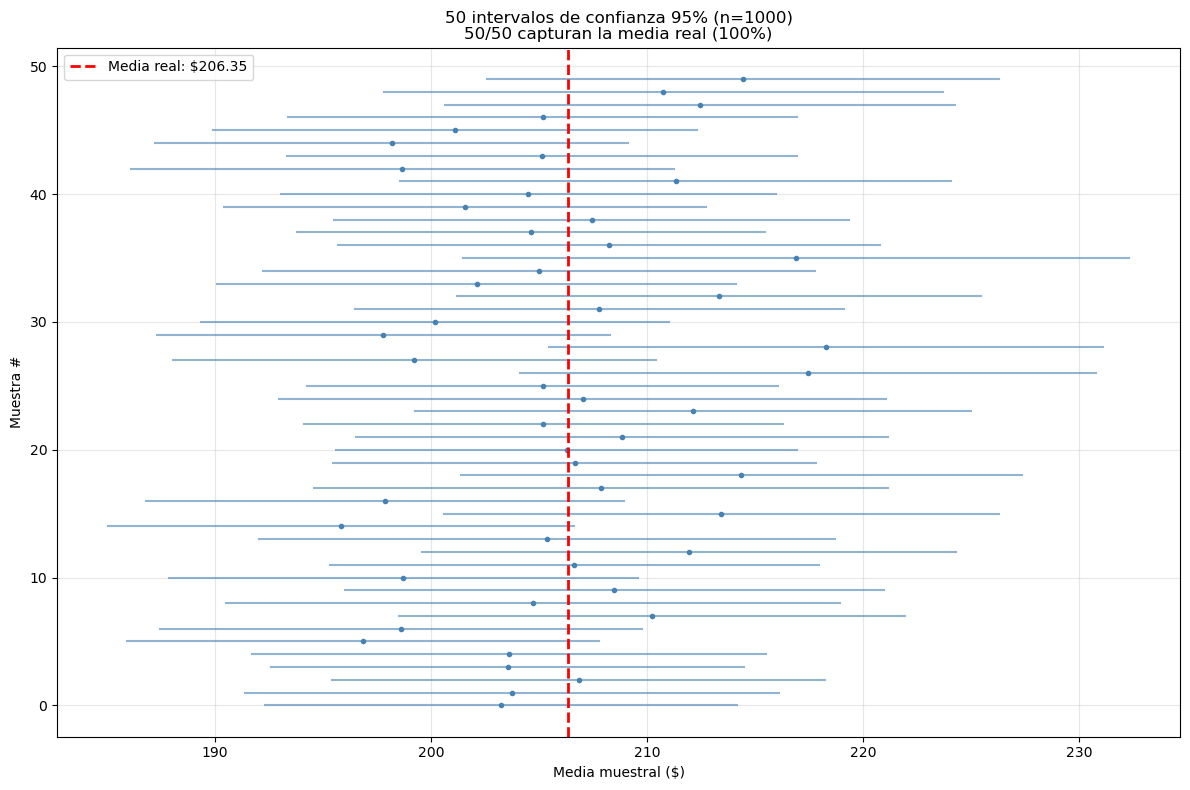

In [3]:
# ============================================================
# S4.3 — ERROR ESTÁNDAR E INTERVALOS DE CONFIANZA
# ============================================================

# Error Estándar (SE): qué tan dispersas están las medias muestrales
# Fórmula: SE = σ / √n
# Cuanto mayor n → menor SE → más precisa la estimación

# Intervalo de Confianza (IC): rango donde cae la media real
# con cierta probabilidad
# Fórmula IC 95%: x̄ ± 1.96 * SE

print("=== ERROR ESTÁNDAR ===")
print(f"σ poblacional: ${poblacion.std():.2f}")
print()

for n in [30, 100, 500, 1000]:
    muestra = np.random.choice(poblacion, size=n, replace=False)
    media_m = muestra.mean()
    se = muestra.std() / np.sqrt(n)          # Error estándar
    margen = 1.96 * se                        # IC 95%
    ic_inf = media_m - margen
    ic_sup = media_m + margen
    dentro = ic_inf <= media_real <= ic_sup

    print(f"n={n:4d} | Media: ${media_m:.2f} | "
          f"SE: ${se:.2f} | "
          f"IC 95%: [${ic_inf:.2f}, ${ic_sup:.2f}] | "
          f"{'✅ captura la media real' if dentro else '❌ no captura'}")

print()
print("=== VISUALIZACIÓN IC para n=1000 ===")

# Tomar 50 muestras y ver cuántos IC capturan la media real
fig, ax = plt.subplots(figsize=(12, 8))
capturados = 0

for i in range(50):
    muestra = np.random.choice(poblacion, size=1000, replace=False)
    media_m = muestra.mean()
    se = muestra.std() / np.sqrt(1000)
    ic_inf = media_m - 1.96 * se
    ic_sup = media_m + 1.96 * se
    dentro = ic_inf <= media_real <= ic_sup
    if dentro:
        capturados += 1

    color = 'steelblue' if dentro else 'red'
    ax.plot([ic_inf, ic_sup], [i, i], color=color, alpha=0.6, linewidth=1.5)
    ax.plot(media_m, i, 'o', color=color, markersize=3)

ax.axvline(media_real, color='red', linewidth=2,
           linestyle='--', label=f'Media real: ${media_real:.2f}')
ax.set_xlabel('Media muestral ($)')
ax.set_ylabel('Muestra #')
ax.set_title(f'50 intervalos de confianza 95% (n=1000)\n'
             f'{capturados}/50 capturan la media real ({capturados*2}%)')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/S4.3_intervalos_confianza.png', dpi=150, bbox_inches='tight')
plt.show()

In [4]:
# ============================================================
# S4.3 — APLICACIÓN PRÁCTICA: FARMACIAS
# ============================================================
# Pregunta de negocio:
# "¿Cuál es el ticket promedio real de Farmacias?
#  Solo tengo acceso a una muestra — ¿qué tan confiable es?"

np.random.seed(99)

# Simular que solo tienes acceso a una muestra de 500 tickets
muestra_farmacias = np.random.choice(poblacion, size=500, replace=False)

media_m  = muestra_farmacias.mean()
se       = muestra_farmacias.std() / np.sqrt(len(muestra_farmacias))

# Intervalos para diferentes niveles de confianza
niveles = [(0.90, 1.645, "90%"), (0.95, 1.960, "95%"), (0.99, 2.576, "99%")]

print("=== ESTIMACIÓN DEL TICKET PROMEDIO — FARMACIAS ===")
print(f"Muestra: n={len(muestra_farmacias):,} tickets")
print(f"Media muestral: ${media_m:.2f}")
print(f"Error estándar: ${se:.2f}")
print()
print("Intervalos de confianza:")
print("-" * 60)

for nivel, z, label in niveles:
    ic_inf = media_m - z * se
    ic_sup = media_m + z * se
    amplitud = ic_sup - ic_inf
    print(f"IC {label}: [${ic_inf:.2f}, ${ic_sup:.2f}]  "
          f"amplitud: ${amplitud:.2f}")

print()
print(f"Media real poblacional: ${media_real:.2f}")
print()
print("=== INTERPRETACIÓN DE NEGOCIO ===")
ic_inf_95 = media_m - 1.96 * se
ic_sup_95 = media_m + 1.96 * se
print(f"Con 95% de confianza, el ticket promedio real de Farmacias")
print(f"está entre ${ic_inf_95:.2f} y ${ic_sup_95:.2f}")
print(f"Esto significa: si tomamos 100 muestras distintas de n=500,")
print(f"~95 de esos intervalos contendrán el valor real.")

=== ESTIMACIÓN DEL TICKET PROMEDIO — FARMACIAS ===
Muestra: n=500 tickets
Media muestral: $196.89
Error estándar: $8.29

Intervalos de confianza:
------------------------------------------------------------
IC 90%: [$183.25, $210.52]  amplitud: $27.28
IC 95%: [$180.64, $213.14]  amplitud: $32.50
IC 99%: [$175.53, $218.24]  amplitud: $42.71

Media real poblacional: $206.35

=== INTERPRETACIÓN DE NEGOCIO ===
Con 95% de confianza, el ticket promedio real de Farmacias
está entre $180.64 y $213.14
Esto significa: si tomamos 100 muestras distintas de n=500,
~95 de esos intervalos contendrán el valor real.
